<a href="https://colab.research.google.com/github/nguyentrungtin123/thuchanh_deeplearning/blob/main/bai_th_deep_buoii03_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

2.1. Nạp thư viện

In [4]:
import pandas as pd
import numpy as np
import tensorflow as tf
import keras
from keras.layers import Conv2D, Dense, MaxPool2D, Flatten, Input
from keras.models import Sequential
import matplotlib.pyplot as plt

2.2. Đọc dữ liệu MNIST

In [5]:
mnist_train = '/content/sample_data/mnist_train_small.csv'
mnist_test = '/content/sample_data/mnist_test.csv'
df_train = pd.read_csv(mnist_train)
df_test = pd.read_csv(mnist_test)

print(df_train.shape)
X_train = df_train.iloc[:, 1:]
y_train = df_train.iloc[:, 0]
X_test = df_test.iloc[:, 1:]
y_test = df_test.iloc[:, 0]
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

num_classes = 10
input_shape = (28, 28, 1)
X_train = X_train.astype("float32") / 255
X_test = X_test.astype("float32") / 255
X_train = X_train.to_numpy()
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
print(X_train.shape)
X_test = X_test.to_numpy()
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)
print(X_test.shape)

print('Number of classes:', len(np.unique(y_train)))
print('Classes:', np.unique(y_train))
print(y_train[:5])

(19999, 785)
(19999, 784) (19999,) (9999, 784) (9999,)
(19999, 28, 28, 1)
(9999, 28, 28, 1)
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]
0    5
1    7
2    9
3    5
4    2
Name: 6, dtype: int64


2.3. Trực quan hóa 10 ảnh đầu tiên

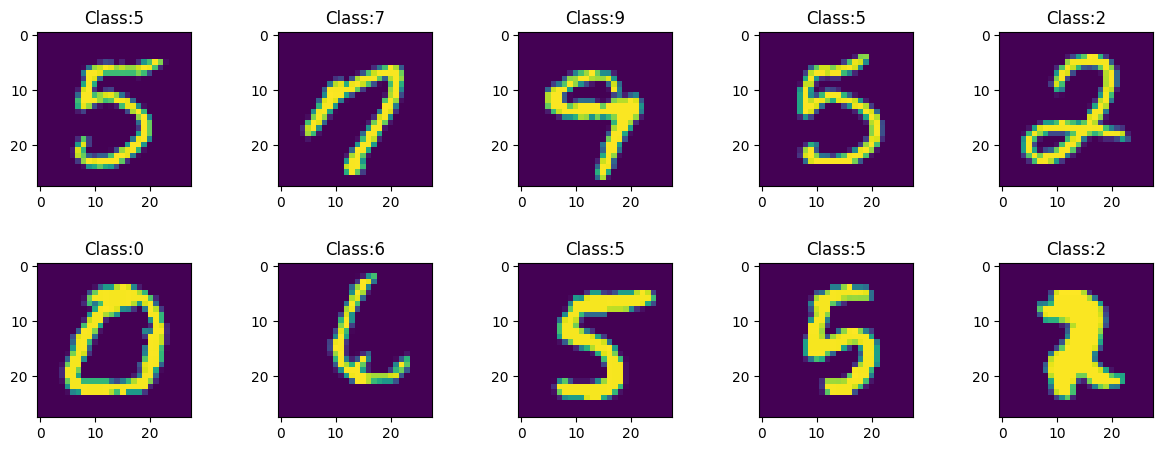

In [6]:
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 5))
ax = axes.ravel()
for i in range(10):
    ax[i].imshow(X_train[i].reshape(28, 28))
    ax[i].title.set_text('Class:' + str(y_train[i]))
plt.subplots_adjust(hspace=0.5)
plt.show()

2.4. Chuyển giá trị nhãn thành one-hot encoding


In [7]:
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)


2.5. Xây dựng mô hình CNN

In [8]:
model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(units=10, activation='softmax'))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

2.6. Huấn luyện mô hình CNN

In [9]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_fit = model.fit(X_train, y_train, batch_size=128, epochs=15, validation_split=0.1, verbose=1)

Epoch 1/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 20s 115ms/step - accuracy: 0.8299 - loss: 0.6093 - val_accuracy: 0.9355 - val_loss: 0.2370
Epoch 2/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 17s 118ms/step - accuracy: 0.9552 - loss: 0.1506 - val_accuracy: 0.9600 - val_loss: 0.1332
Epoch 3/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 16s 116ms/step - accuracy: 0.9701 - loss: 0.0978 - val_accuracy: 0.9695 - val_loss: 0.0981
Epoch 4/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 19s 103ms/step - accuracy: 0.9769 - loss: 0.0761 - val_accuracy: 0.9740 - val_loss: 0.0867
Epoch 5/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 15s 103ms/step - accuracy: 0.9802 - loss: 0.0635 - val_accuracy: 0.9765 - val_loss: 0.0796
Epoch 6/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 16s 113ms/step - accuracy: 0.9835 - loss: 0.0533 - val_accuracy: 0.9780 - val_loss: 0.0765
Epoch 7/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 19s 132ms/step - accuracy: 0.9860 - loss: 0.0444 - val_accuracy: 0.9795 - val_loss: 0.0687
Epoch 8/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 20s 127ms/step - accuracy: 0.9877 - loss: 0

2.7. Đánh giá mô hình CNN (Độ chính xác)

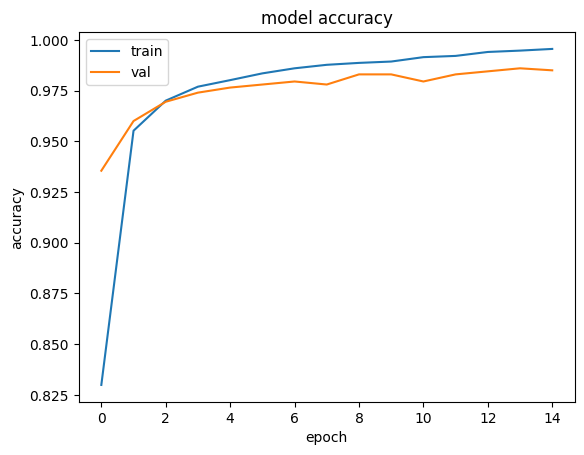

In [10]:
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

2.8. Đánh giá mô hình CNN thử nghiệm trên tập test

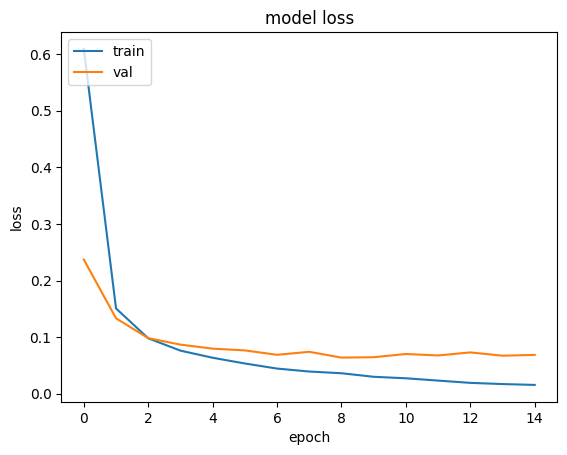

313/313 - 4s - 11ms/step - accuracy: 0.9828 - loss: 0.0557
Test loss: 0.055704765021800995
Test accuracy: 0.9827982783317566


In [11]:
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

score = model.evaluate(X_test, y_test, verbose=2)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

2.9. Dự báo nhãn cho ảnh sử dụng CNN

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
[[1.3030828e-03 3.0567874e-03 9.9563992e-01 2.4361815e-09 5.5886426e-21
  8.4221862e-14 1.7738579e-07 1.6471136e-17 2.6708657e-08 3.4842482e-20]]
2 2


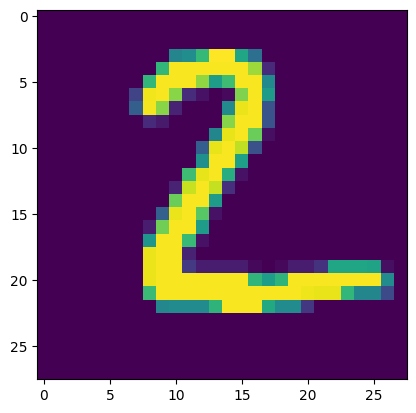

In [12]:
predict = model.predict(X_test[:1])
print(predict)
print(np.argmax(predict), np.argmax(y_test[0]))
plt.imshow(X_test[:1].reshape(28, 28))
plt.show()

2.10. Lưu tham số mô hình CNN

In [14]:
model.save_weights('cnn.weights.h5')

2.11. Nạp lại mô hình và tham số

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
[[1.2009342e-07 9.9995971e-01 1.2034326e-05 9.5936755e-08 1.9276886e-05
  2.7733179e-07 9.7329644e-07 3.1172644e-06 4.3835134e-06 4.2470929e-09]]
1 1


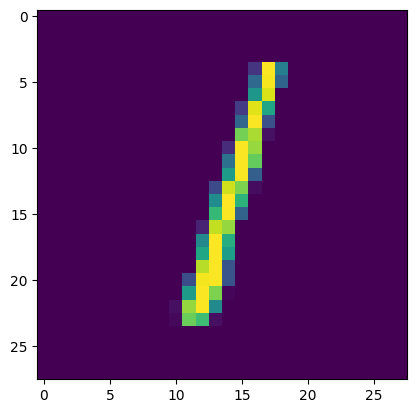

In [17]:
model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(units=10, activation='softmax'))
model.load_weights('cnn.weights.h5')

predict = model.predict(X_test[1:2])
print(predict)
print(np.argmax(predict), np.argmax(y_test[1]))
plt.imshow(X_test[1:2].reshape(28, 28))
plt.show()